# InceptionV3 Transfer Learning with Flowers Dataset
This notebook demonstrates how to perform transfer learning using InceptionV3 in Keras with a multi-class Flowers RGB dataset.

In [1]:
!nvidia-smi

Wed Aug 19 20:09:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install split-folders -q

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import InceptionV3,preprocess_input
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

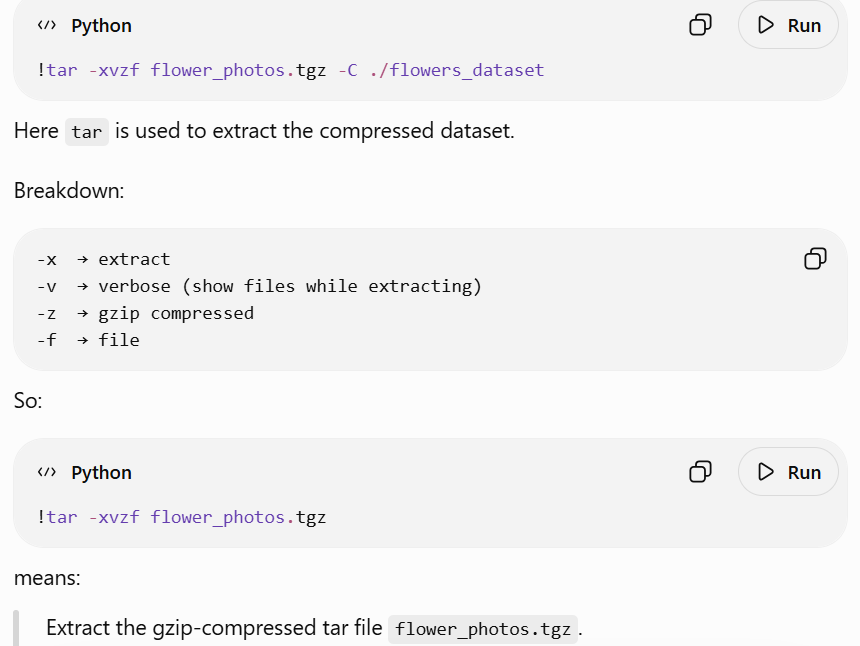

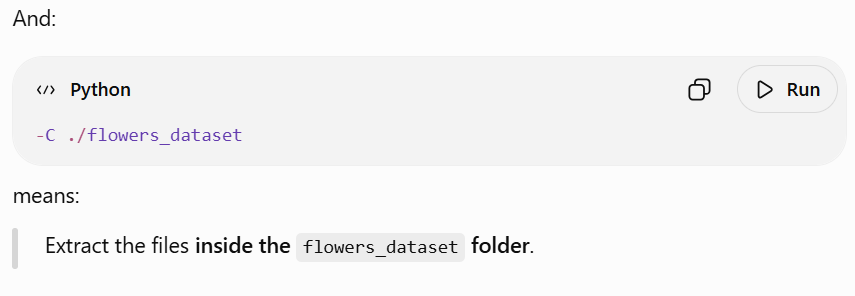

In [4]:
# Download and unzip dataset
!wget https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
!mkdir -p ./flowers_dataset
!tar -xvzf flower_photos.tgz -C ./flowers_dataset

--2026-08-19 20:10:05--  https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
Resolving storage.googleapis.com (storage.googleapis.com)... 104.154.125.27, 34.153.2.27, 34.153.3.27, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|104.154.125.27|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228813984 (218M) [application/x-compressed-tar]
Saving to: ‘flower_photos.tgz’

flower_photos.tgz   100%[===================>] 218.21M   186MB/s    in 1.2s    

2026-08-19 20:10:06 (186 MB/s) - ‘flower_photos.tgz’ saved [228813984/228813984]

flower_photos/
flower_photos/roses/
flower_photos/roses/14810868100_87eb739f26_m.jpg
flower_photos/roses/1446090416_f0cad5fde4.jpg
flower_photos/roses/15319767030_e6c5602a77_m.jpg
flower_photos/roses/15032112248_30c5284e54_n.jpg
flower_photos/roses/7211616670_2d49ecb3a5_m.jpg
flower_photos/roses/15674450867_0ced942941_n.jpg
flower_photos/roses/17158274118_00ec99a23c.jpg
flower_photos

In [5]:
# split flowers
import splitfolders
splitfolders.ratio("/content/flowers_dataset/flower_photos",output="flower_split",seed=42,ratio=[0.7,0.2,0.1])

Copying files: 3670 files [00:01, 3302.47 files/s]


In [6]:
img_size = (299,299)
batch_size = 64

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,zoom_range = 0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    'flower_split/train',target_size=img_size,batch_size=batch_size,class_mode='categorical'
)


valid_generator = val_datagen.flow_from_directory(
    'flower_split/val',target_size=img_size,batch_size=batch_size,class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    'flower_split/test',target_size=img_size,batch_size=batch_size,class_mode='categorical',shuffle=False
)

Found 2567 images belonging to 5 classes.
Found 731 images belonging to 5 classes.
Found 372 images belonging to 5 classes.


In [7]:
train_generator.num_classes

5

In [8]:
train_generator.num_batches

41

***Transfer Learning***

In [9]:
# Load InceptionV3 and add custom layers
base_model = InceptionV3(weights='imagenet',include_top=False,input_shape=(299,299,3))
for layer in base_model.layers:
  layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024,activation='relu')(x)
prediction = Dense(train_generator.num_classes,activation='softmax')(x)


model = Model(inputs=base_model.input,outputs=prediction)
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics = ['accuracy'])
model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 23,906,085 (91.19 MB)

 Trainable params: 2,103,301 (8.02 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [10]:
hist = model.fit(
    train_generator,epochs=10,
    validation_data = valid_generator
    )

Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.6860 - loss: 0.8334 - val_accuracy: 0.8263 - val_loss: 0.5211
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.8516 - loss: 0.4455 - val_accuracy: 0.8687 - val_loss: 0.4066
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.8859 - loss: 0.3622 - val_accuracy: 0.8755 - val_loss: 0.3811
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.8975 - loss: 0.3146 - val_accuracy: 0.8837 - val_loss: 0.3494
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.9100 - loss: 0.2865 - val_accuracy: 0.8714 - val_loss: 0.3551
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.9143 - loss: 0.2619 - val_accuracy: 0.8796 - val_loss: 0.3203
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.9178 - loss: 0.2411 - val_accuracy: 0.8851 - val_loss: 0.3042
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.9264 - loss: 0.2226 - val_accuracy: 0.8851 - val_loss

In [12]:
hist.history

{'accuracy': [0.6860148310661316,
  0.8515776991844177,
  0.885858952999115,
  0.8975457549095154,
  0.9100117087364197,
  0.9142968654632568,
  0.9178028702735901,
  0.9263731837272644,
  0.9357226490974426,
  0.9415660500526428],
 'loss': [0.8333616852760315,
  0.4455273449420929,
  0.3622487187385559,
  0.314558207988739,
  0.28648850321769714,
  0.26188749074935913,
  0.24110651016235352,
  0.22263981401920319,
  0.2114402800798416,
  0.19058671593666077],
 'val_accuracy': [0.8262653946876526,
  0.8686730265617371,
  0.8755130171775818,
  0.8837209343910217,
  0.871408998966217,
  0.8796169757843018,
  0.8850889205932617,
  0.8850889205932617,
  0.9015048146247864,
  0.8974007964134216],
 'val_loss': [0.5210579633712769,
  0.4065608084201813,
  0.3810904622077942,
  0.34935328364372253,
  0.35512328147888184,
  0.32028961181640625,
  0.30419403314590454,
  0.3132264018058777,
  0.29597628116607666,
  0.29555994272232056]}

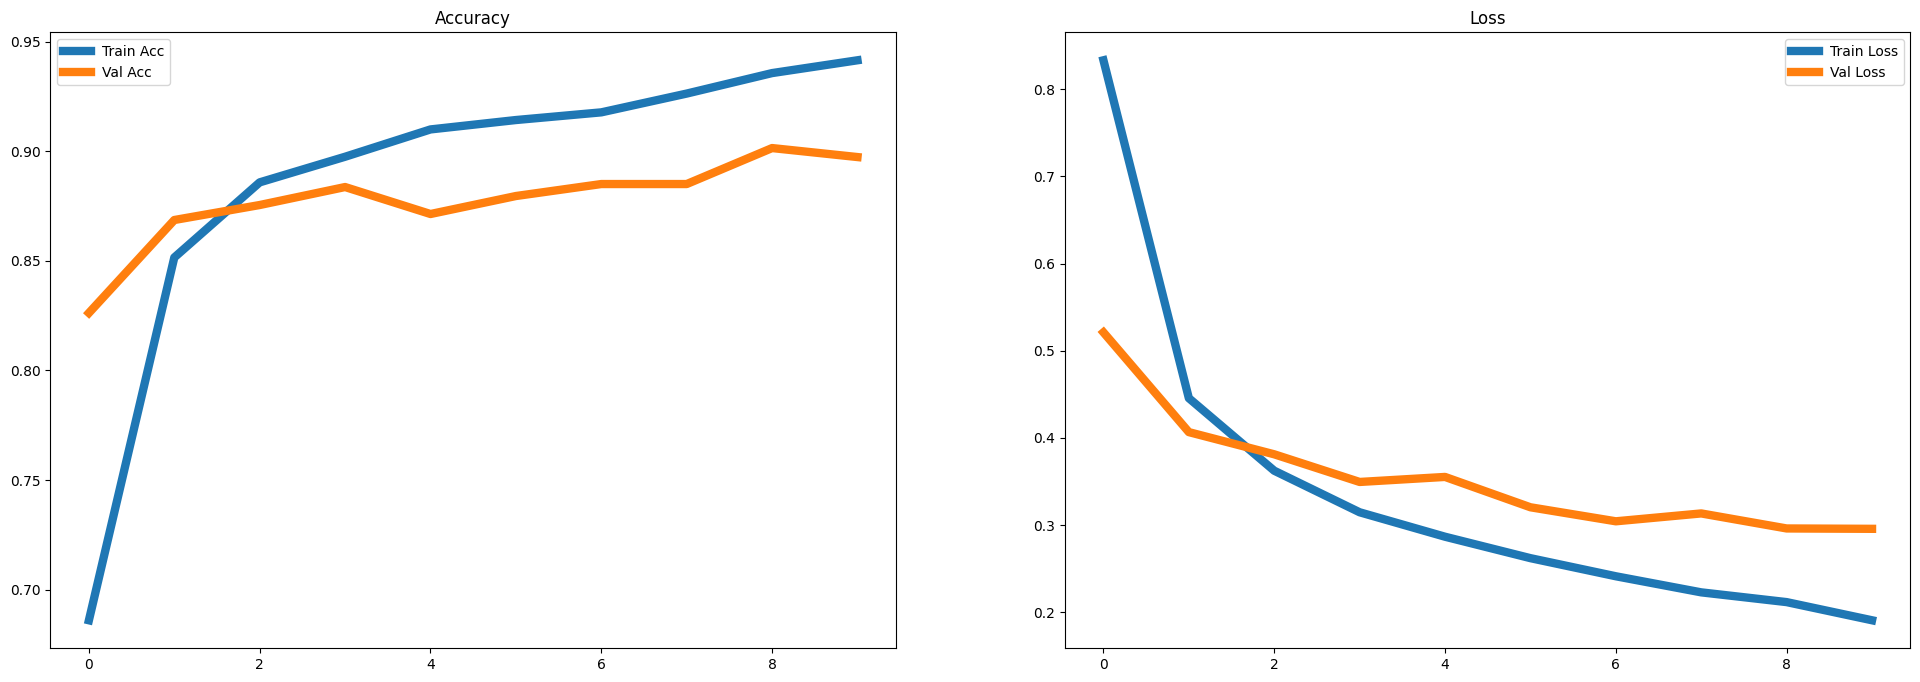

In [16]:
plt.figure(figsize=(24,8))
plt.subplot(1,2,1)
plt.plot(hist.history['accuracy'],label='Train Acc',linewidth=6)
plt.plot(hist.history['val_accuracy'],label='Val Acc',linewidth=6)
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(hist.history['loss'],label='Train Loss',linewidth=6)
plt.plot(hist.history['val_loss'],label='Val Loss',linewidth=6)
plt.legend()
plt.title('Loss')
plt.show()

In [17]:
loss,acc = model.evaluate(test_generator)
print(f"Test Accuracy: {acc:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.8952 - loss: 0.3147
Test Accuracy: 0.8952


In [20]:
from tensorflow.keras.preprocessing import image

def predict_img(img_pth):
  img = image.load_img(img_pth,target_size=img_size)
  img_array = image.img_to_array(img)
  img_array = preprocess_input(img_array)
  img_array = np.expand_dims(img_array,axis=0)
  preds = model.predict(img_array)
  class_index = np.argmax(preds[0])
  class_label = list(train_generator.class_indices.keys())[class_index]
  print(f"Prediction: {class_label} ({preds[0][class_index]*100:.2f}%)")
  print(preds)
  plt.imshow(img)
  plt.axis('off')
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Prediction: daisy (99.38%)
[[9.9379528e-01 2.2168361e-04 7.6004013e-05 5.7540103e-03 1.5304566e-04]]


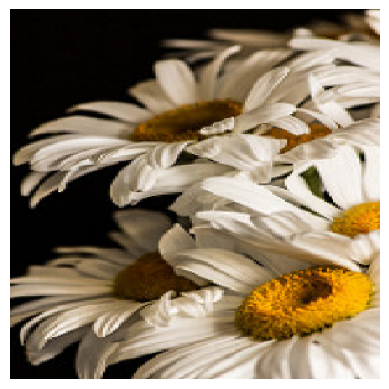

In [21]:
predict_img('/content/flower_split/test/daisy/11023277956_8980d53169_m.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Prediction: dandelion (98.86%)
[[2.4029575e-03 9.8858160e-01 1.0623080e-03 7.2827558e-03 6.7046948e-04]]


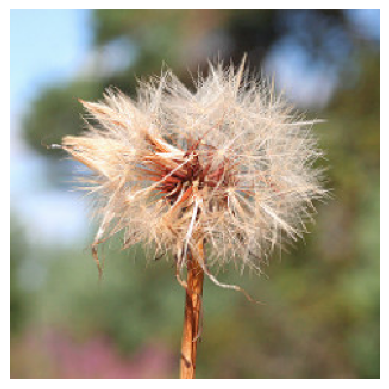

In [22]:
predict_img('/content/flower_split/test/dandelion/1413979148_b40d63db90_m.jpg')